# Normative Uncertainty in IAMs

## Section 1a: Hypervolume Calculation and Visualization

Tests convergence of the MMBorg multi-master optimization across seeds and SSP scenarios
for both the Prioritarian and Utilitarian social welfare functions.

**Workflow:**

1. **Reference set generation** — combines the final archives from all seeds (MMBorg islands)
   into a single epsilon-nondominated reference set per experiment folder. This global
   reference set serves as the benchmark Pareto front for hypervolume calculations.

2. **Hypervolume computation** — for each seed archive, computes the hypervolume indicator
   at every recorded NFE snapshot against the global reference set. A higher hypervolume
   indicates a better-converged approximation of the Pareto front.

3. **Convergence plots** — plots hypervolume vs. number of function evaluations for all
   seeds within each (SWF, SSP) combination. Convergence across seeds indicates that the
   optimizer has found a stable Pareto front approximation.

**Output:** SVG plots saved to `reproduce/plots/`, one per (SWF, SSP) combination.

In [1]:
# ── Section 1a: Hypervolume Calculation and Visualization ─────────────────────

from solvers.convergence.hypervolume import (
    get_global_reference_set,
    calculate_hypervolume_from_archives,
)
from justice.util.enumerations import WelfareFunction, SSP
from justice.util.visualizer import plot_hypervolume

import glob
import multiprocessing
import os
import re
import warnings

warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path = "data/temporary/NU_DATA/mmBorg/reproduce"
plots_dir = f"{base_path}/plots"
os.makedirs(plots_dir, exist_ok=True)

nfe = 100_000

swf_list = [
    WelfareFunction.PRIORITARIAN,
    WelfareFunction.UTILITARIAN,
]

ssp_list = [
    SSP.SSP1,
    SSP.SSP2,
    SSP.SSP3,
    SSP.SSP4,
    SSP.SSP5,
]

list_of_objectives        = ["welfare", "fraction_above_threshold"]
direction_of_optimization = ["min", "min"]
epsilons                  = [0.00001, 0.001]

# ── HELPER: discover archives in a folder ─────────────────────────────────────
# Matches: {swf_tag}_{nfe}_ref{N}_42_{seed}.tar.gz  (any ref, any seed)
def find_archives(path: str, swf_tag: str, nfe: int) -> list[str]:
    pattern = os.path.join(path, f"{swf_tag}_{nfe}_ref*_42_*.tar.gz")
    files   = sorted(glob.glob(pattern))
    return [os.path.basename(f) for f in files]

# ── REFERENCE SETS ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Generating reference sets")
print("=" * 60)

for swf in swf_list:
    for ssp in ssp_list:
        ssp_name = str(ssp).split(".")[1]
        path     = f"{base_path}/{swf.value[1]}_{ssp_name}"

        archives = find_archives(path, swf.value[1], nfe)
        if not archives:
            print(f"  SKIP  {swf.value[1]}/{ssp_name}  — no archives found")
            continue

        print(f"  {swf.value[1]}/{ssp_name}  ({len(archives)} archives)")

        get_global_reference_set(
            list_of_objectives        = list_of_objectives,
            data_path                 = path,
            swf                       = [swf.value[1]],
            nfe                       = str(nfe),
            epsilons                  = epsilons,
            direction_of_optimization = direction_of_optimization,
            output_data_path          = path,
            saving                    = True,
        )

print()

# ── HYPERVOLUME COMPUTATION ────────────────────────────────────────────────────
# HV CSVs are written to path/hv/ to keep them out of the archive folder.
# load_archives_all_seeds globs the parent folder by prefix — mixing CSVs
# and tar.gz files there causes a ReadError.
print("=" * 60)
print("Computing hypervolumes")
print("=" * 60)

with multiprocessing.Pool() as pool:
    for swf in swf_list:
        for ssp in ssp_list:
            ssp_name = str(ssp).split(".")[1]
            path     = f"{base_path}/{swf.value[1]}_{ssp_name}"
            hv_path  = f"{path}/hv"
            os.makedirs(hv_path, exist_ok=True)

            refset   = f"{swf.value[1]}_reference_set.csv"
            archives = find_archives(path, swf.value[1], nfe)
            if not archives:
                print(f"  SKIP  {swf.value[1]}/{ssp_name}  — no archives found")
                continue

            print(f"  {swf.value[1]}/{ssp_name}  ({len(archives)} archives)")
            for filename in archives:
                print(f"    {filename}")
                calculate_hypervolume_from_archives(
                    list_of_objectives        = list_of_objectives,
                    direction_of_optimization = direction_of_optimization,
                    input_data_path           = path,
                    file_name                 = filename,
                    output_data_path          = hv_path,
                    saving                    = True,
                    global_reference_set      = True,
                    global_reference_set_path = path,
                    global_reference_set_file = refset,
                    pool                      = pool,
                )

print()

# ── HYPERVOLUME PLOTS → reproduce/plots/ ──────────────────────────────────────
print("=" * 60)
print(f"Saving plots → {plots_dir}/")
print("=" * 60)

for swf in swf_list:
    for ssp in ssp_list:
        ssp_name = str(ssp).split(".")[1]
        path     = f"{base_path}/{swf.value[1]}_{ssp_name}"
        hv_path  = f"{path}/hv"

        archives = find_archives(path, swf.value[1], nfe)
        if not archives:
            continue

        refs = sorted({
            int(re.search(r"_ref(\d+)_", f).group(1))
            for f in archives
            if re.search(r"_ref(\d+)_", f)
        })

        for ssp_ref in refs:
            hv_files = sorted(glob.glob(
                os.path.join(hv_path, f"{swf.value[1]}_{nfe}_ref{ssp_ref}_42_*_hv.csv")
            ))

            if not hv_files:
                print(f"  SKIP  {swf.value[1]}/{ssp_name}/ref{ssp_ref}  — no HV files found")
                continue

            print(f"  {swf.value[1]}/{ssp_name}/ref{ssp_ref}  ({len(hv_files)} seeds)")

            fig = plot_hypervolume(
                path_to_data      = hv_path,
                path_to_output    = plots_dir,
                input_data        = {f"{swf.value[1]}_{ssp_name}": [os.path.basename(f) for f in hv_files]},
                yaxis_upper_limit = 1.0,
                width             = 1000,
                height            = 800,
                fontsize          = 20,
                saving            = True,
            )
            # fig.show()

print("\nDone.")

Generating reference sets
  PRIORITARIAN/SSP1  (5 archives)
Loading list of files
Loading archives for:  PRIORITARIAN
Filename:  PRIORITARIAN_100000_ref1_42_3.tar.gz
Matching file: PRIORITARIAN_100000_ref1_42_3.tar.gz
Loading archives from: PRIORITARIAN_100000_ref1_42_3.tar.gz
Max key: 100000
Number of rows in archive: 4
Archives loaded for: PRIORITARIAN_100000_ref1_42_3.tar.gz
Filename:  0_SSP534_PRIORITARIAN_global_temperature_.csv
Filename:  2_SSP370_PRIORITARIAN_global_temperature_.csv
Filename:  0_SSP126_PRIORITARIAN_global_temperature_.csv
Filename:  .DS_Store
Filename:  0_SSP460_PRIORITARIAN_global_temperature_.csv
Filename:  PRIORITARIAN_100000_ref1_42_1.tar.gz
Matching file: PRIORITARIAN_100000_ref1_42_1.tar.gz
Loading archives from: PRIORITARIAN_100000_ref1_42_1.tar.gz
Max key: 100000
Number of rows in archive: 4
Archives loaded for: PRIORITARIAN_100000_ref1_42_1.tar.gz
Filename:  hv
Filename:  2_SSP245_PRIORITARIAN_global_temperature_.csv
Filename:  3_SSP126_PRIORITARIAN_glo

## Section 1b: Pareto Front Re-evaluation and Outcome Mapping

Re-evaluates all Pareto-optimal policy candidates from the reference sets across all
(SWF, SSP) combinations under a set of deep uncertainty scenarios.

**What the script computes:**
For each Pareto-optimal policy index, the model is re-run across 5 SSP forcing scenarios
(SSP126, SSP245, SSP370, SSP460, SSP534) to collect the following outcomes:
- **Global temperature** trajectory over time
- **Utilitarian welfare** trajectory over time
- **Prioritarian welfare** trajectory over time

**Output:** Mapping files written to `reproduce/mapping/`, one per (SWF, SSP) combination.

This mapping serves as the input for regret calculations in the next section.

> ⚠ This step is computationally expensive — expect **30 minutes to several hours** per
> combination depending on the number of policy candidates and available resources.
> Combinations run sequentially; parallelise across different machines if available.

In [1]:
%%bash
# ── Section 1b: Regret Mapping — all SWF × SSP combinations ──────────────────

BASE_PATH="data/temporary/NU_DATA/mmBorg/reproduce/"
SWFS=("PRIORITARIAN" "UTILITARIAN")
SSPS=("SSP1" "SSP2" "SSP3" "SSP4" "SSP5")

for SWF in "${SWFS[@]}"; do
    for SSP in "${SSPS[@]}"; do
        echo "========================================"
        echo "Running: ${SWF} / ${SSP}"
        echo "========================================"
        python justice/util/postprocessing_for_regret_calculations.py \
            "${BASE_PATH}" "${SWF}" "${SSP}"

        if [ $? -ne 0 ]; then
            echo "  ✗ FAILED: ${SWF} / ${SSP}"
        else
            echo "  ✓ Done: ${SWF} / ${SSP}"
        fi
    done
done

echo ""
echo "✓ All done. Outputs in ${BASE_PATH}mapping/"

Running: PRIORITARIAN / SSP1


Selected SWF: WelfareFunction.PRIORITARIAN, SSP: 0
Final output: data/temporary/NU_DATA/mmBorg/reproduce/mapping
Loading data for PRIORITARIAN from data/temporary/NU_DATA/mmBorg/reproduce/PRIORITARIAN_SSP1/PRIORITARIAN_reference_set.csv
Selected policy-indices last 2 columns:
      welfare  fraction_above_threshold
0  398.475097                      0.16
1  398.433140                      0.22
2  398.437763                      0.20
3  398.442591                      0.18

--- [PID 24128] Building JUSTICE for SSP126 (1) ---

--- [PID 24127] Building JUSTICE for SSP245 (2) ---

--- [PID 24126] Building JUSTICE for SSP370 (3) ---

--- [PID 24125] Building JUSTICE for SSP460 (5) ---

--- [PID 24129] Building JUSTICE for SSP534 (6) ---
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
index for policy:  0
Fraction above threshold Reeval: 0.44655344655344653
index for policy:  0
Fraction above threshol

Traceback (most recent call last):
  File "<string>", line 1, in <module>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 125, in _main
Traceback (most recent call last):
      File "<string>", line 1, in <module>
exitcode = _main(fd, parent_sentinel)
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 125, in _main
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    prepare(preparation_data)


Error while terminating subprocess (pid=24121): 


#### Section 1b-ii: Running only a single combination of (SWF, SSP)

In [4]:
%%bash
# ── Section 1b-ii (single run) ───────────────────────────────────────────────────
# Use this to run or re-run a specific SWF / SSP combination.

BASE_PATH="data/temporary/NU_DATA/mmBorg/reproduce/"
SWF="UTILITARIAN" # Specify one of: PRIORITARIAN, UTILITARIAN
SSP="SSP2" # Specify one of: SSP1, SSP2, SSP3, SSP4, SSP5

echo "Running: ${SWF} / ${SSP}"
python justice/util/postprocessing_for_regret_calculations.py \
    "${BASE_PATH}" "${SWF}" "${SSP}"

if [ $? -ne 0 ]; then
    echo "  ✗ FAILED: ${SWF} / ${SSP}"
else
    echo "  ✓ Done: ${SWF} / ${SSP}"
fi

Running: UTILITARIAN / SSP2
Selected SWF: WelfareFunction.UTILITARIAN, SSP: 1
Final output: data/temporary/NU_DATA/mmBorg/reproduce/mapping
Loading data for UTILITARIAN from data/temporary/NU_DATA/mmBorg/reproduce/UTILITARIAN_SSP2/UTILITARIAN_reference_set.csv
Selected policy-indices last 2 columns:
       welfare  fraction_above_threshold
0   103.494986                      0.62
1   103.645088                      0.34
2   103.483105                      0.64
3   103.467961                      0.76
4   103.465072                      0.80
5   103.608493                      0.36
6   103.479852                      0.70
7   103.534661                      0.50
8   103.504900                      0.60
9   103.459036                      0.86
10  103.480534                      0.68
11  103.506200                      0.56
12  103.471677                      0.74
13  103.473309                      0.72
14  103.480930                      0.66
15  103.458890                      0.88
16

### Section 1c: Regret Calculation 

In [2]:
# ── Section 1c: Minimax Regret Calculation ────────────────────────────────────

import json
import numpy as np
import pandas as pd
from pathlib import Path

from justice.util.enumerations import WelfareFunction, SSP
from justice.util.output_data_processor import (
    compute_p90_regret_dataframe,
    minimax_regret_policy,
)

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path      = "data/temporary/NU_DATA/mmBorg/reproduce"
regret_dfs_dir = f"{base_path}/regret_dfs"
Path(regret_dfs_dir).mkdir(parents=True, exist_ok=True)

scenario_list   = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]
save_regret_dfs = True

# SSP reference scenario used during optimisation
BASELINE_SCENARIO = {
    "SSP1": "SSP126",
    "SSP2": "SSP245",
    "SSP3": "SSP370",
    "SSP4": "SSP460",
    "SSP5": "SSP534",
}

# Variable and optimisation direction per (ethical_framing, regret_type)
REGRET_CONFIG = {
    ("UTILITARIAN",  "Temperature_Regret"): ("global_temperature",  "min"),
    ("UTILITARIAN",  "Welfare_Regret")    : ("utilitarian_welfare",  "max"),
    ("PRIORITARIAN", "Temperature_Regret"): ("global_temperature",  "min"),
    ("PRIORITARIAN", "Welfare_Regret")    : ("prioritarian_welfare", "max"),
}

SSP_LIST     = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
SWF_LIST     = ["UTILITARIAN", "PRIORITARIAN"]
REGRET_TYPES = ["Temperature_Regret", "Welfare_Regret"]

# ── COMPUTE ────────────────────────────────────────────────────────────────────
min_regret_policy_indices = {}

for ssp_key in SSP_LIST:
    baseline_scenario = BASELINE_SCENARIO[ssp_key]
    min_regret_policy_indices[ssp_key] = {}

    for ethical_framing in SWF_LIST:
        min_regret_policy_indices[ssp_key][ethical_framing] = {}

        for regret_type in REGRET_TYPES:
            variable_of_interest, direction_of_interest = REGRET_CONFIG[
                (ethical_framing, regret_type)
            ]

            print(
                f"  {ethical_framing} / {ssp_key} / {regret_type}"
                f"  [{variable_of_interest}, {direction_of_interest}]"
            )


            p90_delta_df = compute_p90_regret_dataframe(
                base_path              = f"{base_path}/{ethical_framing}_{ssp_key}/",
                welfare_function_name  = ethical_framing,
                baseline_scenario      = baseline_scenario,
                scenario_list          = scenario_list,
                variable_of_interest   = variable_of_interest,
                direction_of_interest  = direction_of_interest,
                mapping_subdir         = str(Path(f"{base_path}/mapping").resolve()),
                hdf5_filename_template = f"mapping_{{}}_{ssp_key}.h5",
                save_df                = save_regret_dfs,
                df_output_path         = f"{regret_dfs_dir}/p90_{ethical_framing}_{ssp_key}_{regret_type}.csv",
            )

            policy_idx = minimax_regret_policy(p90_delta_df)
            print(f"    → min regret policy index: {policy_idx}")

            min_regret_policy_indices[ssp_key][ethical_framing][regret_type] = policy_idx

# ── SAVE ───────────────────────────────────────────────────────────────────────
output_file = f"{base_path}/min_regret_policy_indices.json"
with open(output_file, "w") as f:
    json.dump(min_regret_policy_indices, f, indent=4)

print(f"\n✓ Saved → {output_file}")
print(json.dumps(min_regret_policy_indices, indent=4))

  UTILITARIAN / SSP1 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_UTILITARIAN_SSP1_Temperature_Regret.csv
    → min regret policy index: 6
  UTILITARIAN / SSP1 / Welfare_Regret  [utilitarian_welfare, max]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_UTILITARIAN_SSP1_Welfare_Regret.csv
    → min regret policy index: 4
  PRIORITARIAN / SSP1 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_PRIORITARIAN_SSP1_Temperature_Regret.csv
    → min regret policy index: 0
  PRIORITARIAN / SSP1 / Welfare_Regret  [prioritarian_welfare, max]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_PRIORITARIAN_SSP1_Welfare_Regret.csv
    → min regret policy index: 1
  UTILITARIAN / SSP2 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/re

## Section 2: Visualizations
### Section 2a: Pareto Fronts 


In [3]:
# ── Section 2a: Pareto Front Visualization ─────────────────────────────────────

import json
import pandas as pd
import plotly.graph_objects as go
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path = "data/temporary/NU_DATA/mmBorg/reproduce"
plots_dir = f"{base_path}/plots"

swf_list = [WelfareFunction.PRIORITARIAN, WelfareFunction.UTILITARIAN]
ssp_list = [SSP.SSP1, SSP.SSP2, SSP.SSP3, SSP.SSP4, SSP.SSP5]

# Load min regret indices computed in Section 1c
with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
BG_MARKER_STYLE = dict(
    size  = 8,
    color = "lightgray",
    line  = dict(width=0.5, color="gray"),
)

HIGHLIGHT_MARKER_STYLE = {
    "Welfare_Regret"    : dict(symbol="triangle-up", size=14, color="#fc8d62", line=dict(width=1.0, color="#fc8d62")),
    "Temperature_Regret": dict(symbol="square",      size=13, color="#8da0cb", line=dict(width=1.0, color="#8da0cb")),
}

BASE_LAYOUT = dict(
    plot_bgcolor  = "white",
    paper_bgcolor = "white",
    font          = dict(color="black"),
    xaxis_title   = "Welfare (normalized)",
    yaxis_title   = "Temperature (normalized)",
    legend_title  = "Policy",
    width         = 900,
    height        = 600,
)

# ── COMPUTE + PLOT ─────────────────────────────────────────────────────────────
figs = {}   # keyed by (swf_tag, ssp_tag)

for swf in swf_list:
    for ssp in ssp_list:
        swf_tag = swf.value[1]
        ssp_tag = str(ssp).split(".")[1]
        path    = f"{base_path}/{swf_tag}_{ssp_tag}"

        # Load and normalize reference set (last 2 columns: welfare, fraction_above_threshold)
        df = pd.read_csv(f"{path}/{swf_tag}_reference_set.csv").iloc[:, -2:]

        # Normalize welfare (col 0): min-max then invert (higher = better)
        df.iloc[:, 0] = (df.iloc[:, 0] - df.iloc[:, 0].min()) / (df.iloc[:, 0].max() - df.iloc[:, 0].min())
        df.iloc[:, 0] = 1 - df.iloc[:, 0]

        # Normalize fraction_above_threshold (col 1): invert (lower = better)
        df.iloc[:, 1] = (df.iloc[:, 1] - df.iloc[:, 1].max()) / (df.iloc[:, 1].min() - df.iloc[:, 1].max())

        # Get highlight indices from min regret JSON
        highlight_indices = {
            regret_type: min_regret_policy_indices[ssp_tag][swf_tag][regret_type]
            for regret_type in ["Welfare_Regret", "Temperature_Regret"]
        }
        all_highlight_idx = set(highlight_indices.values())
        df_bg = df[~df.index.isin(all_highlight_idx)]

        # ── PLOT ──
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x          = df_bg.iloc[:, 1],
            y          = df_bg.iloc[:, 0],
            mode       = "markers",
            marker     = BG_MARKER_STYLE,
            name       = "Other policies",
            showlegend = True,
        ))

        for regret_type, idx in highlight_indices.items():
            row = df.loc[idx]
            fig.add_trace(go.Scatter(
                x          = [row.iloc[1]],
                y          = [row.iloc[0]],
                mode       = "markers",
                marker     = HIGHLIGHT_MARKER_STYLE[regret_type],
                name       = regret_type.replace("_", " "),
                showlegend = True,
            ))

        fig.update_layout(
            **BASE_LAYOUT,
            title = dict(text=f"{swf_tag} — {ssp_tag}", x=0.5),
        )
        fig.update_xaxes(showline=True, linewidth=2, linecolor="black", tickfont=dict(size=14))
        fig.update_yaxes(showline=True, linewidth=2, linecolor="black", tickfont=dict(size=14))

        figs[(swf_tag, ssp_tag)] = fig

        # ── EXPORT ──
        save_path = f"{plots_dir}/{swf_tag}_{ssp_tag}_pareto_front.svg"
        fig.write_image(save_path)
        print(f"  ✓ {save_path}")

  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP1_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP2_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP3_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP4_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP5_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP1_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP2_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP3_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP4_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP5_pareto_front.svg


## Section 3a: Policy Reevaluation and Variable Extraction

For each minimax-regret policy identified in Section 1c, this block re-runs the full
JUSTICE model across all 5 deep uncertainty scenarios (SSP126–SSP534) to extract
time-series outputs for downstream visualization and analysis.

**What this block computes:**
- **Emissions** — global total emissions trajectory (GtCO₂) over 2015–2300
- **Constrained emission control rate** — the policy-prescribed abatement rate per region over time

For each (SWF × SSP × regret type) combination, a temporary HDF5 file is written to
`reproduce/`, variables are extracted as `.npy` arrays, and the HDF5 is deleted to
free disk space.

**Output:** `.npy` files saved to `reproduce/model_outputs/`, named as:
`{SWF}_{SSP}_{RegretType}_{variable}_{scenario}.npy`

> ⚠ **This block is computationally expensive — expect 40–60 minutes total** for all
> 20 combinations (2 SWFs × 5 SSPs × 2 regret types). It also generates several GBs
> of intermediate data. Ensure at least **100 GB of free disk space** before running.
> The temporary HDF5 files are deleted automatically after extraction.

In [1]:
# ── Section 3: Policy Reevaluation and Variable Extraction ────────────────────

import json
import os
import pandas as pd
from pathlib import Path

from justice.util.output_data_processor import (
    reevaluate_optimal_policy,
    reevaluated_optimal_policy_variable_extractor,
)
from justice.util.model_time import TimeHorizon
from justice.util.data_loader import DataLoader
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
Path(model_output_dir).mkdir(parents=True, exist_ok=True)

scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

VARIABLE_CONFIG = {
    "emissions"                        : 3,
    "constrained_emission_control_rate": 3,
}

# ── SETUP ──────────────────────────────────────────────────────────────────────
data_loader   = DataLoader()
region_list   = data_loader.REGION_LIST
time_horizon  = TimeHorizon(
    start_year    = 2015,
    end_year      = 2300,
    data_timestep = 5,
    timestep      = 1,
)
list_of_years = time_horizon.model_time_horizon

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── REEVALUATE + EXTRACT ───────────────────────────────────────────────────────
for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            swf  = WelfareFunction[ethical_framing]
            path = f"{base_path}/{ethical_framing}_{ssp_key}/"

            print(f"\n{'='*60}")
            print(f"  {ethical_framing} / {ssp_key} / {regret_type}  (policy idx {policy_index})")
            print(f"{'='*60}")

            # ── REEVALUATE ─────────────────────────────────────────────────────
            # path_to_output uses trailing slash — function concatenates without sep
            reevaluate_optimal_policy(
                input_data                = [f"{swf.value[1]}_reference_set.csv"],
                path_to_rbf_weights       = path,
                path_to_output            = f"{base_path}/",
                direction_of_optimization = ["min", "min"],
                rbf_policy_index          = policy_index,
                list_of_objectives        = ["welfare", "fraction_above_threshold"],
                scenario_list             = scenario_list,
                reference_scenario        = ssp_key,
                regret_type               = regret_type,
            )

            # h5 written to base_path/ by reevaluate_optimal_policy
            h5_name = (
                f"{ethical_framing}_reference_set"
                f"_ref_{ssp_key}_{regret_type}_idx{policy_index}.h5"
            )

            # ── EXTRACT VARIABLES ──────────────────────────────────────────────
            for variable_name, data_shape in VARIABLE_CONFIG.items():
                output_stem = f"{ethical_framing}_{ssp_key}_{regret_type}_{variable_name}"

                reevaluated_optimal_policy_variable_extractor(
                    scenario_list     = scenario_list,
                    region_list       = region_list,
                    list_of_years     = list_of_years,
                    path_to_data      = base_path,
                    path_to_output    = model_output_dir,
                    variable_name     = variable_name,
                    data_shape        = data_shape,
                    no_of_ensembles   = 1001,
                    input_data        = [h5_name],
                    output_file_names = [output_stem],
                )
                print(f"  ✓ {model_output_dir}/{output_stem}_<scenario>.npy")

            # ── CLEANUP: delete temporary h5 ──────────────────────────────────
            h5_full = f"{base_path}/{h5_name}"
            if os.path.exists(h5_full):
                os.remove(h5_full)
                print(f"  🗑  Deleted: {h5_name}")
            else:
                print(f"  ⚠ h5 not found for cleanup: {h5_full}")

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  UTILITARIAN / SSP1 / Temperature_Regret  (policy idx 6)
index for policy:  6
1 SSP126
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126'])
2 SSP245
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245'])
3 SSP370
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370'])
5 SSP460
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370', 'SSP460'])
6 SSP534
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370', 'SSP460', 'SSP534'])
Saving file as  UTILITARIAN_reference_set
File saved as UTILITARIAN_reference_set_ref_SSP1_Temperature_Regret_idx6 at location data/temporary/NU_DATA/mmBorg/reproduce/
Directory:  /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE
SSP126
File saved as UTILITARIAN_SSP1_Temperature_Regret_emissions_idx6_SSP126_emissions at location data/temporary/NU_DATA/mmBorg/reproduce/model_o

### Section 3b:Emission Pathway Visualization

In [1]:
# ── Section 3b: Emission Pathway Visualization ────────────────────────────────

import json
import numpy as np
import pandas as pd
from justice.util.visualizer import plot_comparison_with_boxplots
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
plots_dir        = f"{base_path}/plots"

variable_name = "emissions"

scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]
scenario_labels = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
LINE_COLORS = [
    "rgba(141,211,199, 1)",
    "rgba(254,217,166, 1)",
    "rgba(190,186,218, 1)",
    "rgba(128,177,211, 1)",
    "rgba(251,128,114, 1)",
]

FILL_COLORS = [
    "rgba(141,211,199, 0.4)",
    "rgba(254,217,166, 0.4)",
    "rgba(190,186,218, 0.4)",
    "rgba(128,177,211, 0.4)",
    "rgba(251,128,114, 0.4)",
]

PLOT_STYLE = dict(
    start_year                = 2015,
    end_year                  = 2300,
    data_timestep             = 5,
    timestep                  = 1,
    visualization_start_year  = 2015,
    visualization_end_year    = 2100,
    yaxis_range               = [0, 80],
    plot_title                = " ",
    xaxis_title               = "Year",
    yaxis_title               = "Global Emissions (GtCO₂)",
    template                  = "plotly_white",
    width                     = 1000,
    height                    = 700,
    saving                    = True,
    show_red_dashed_line      = False,
    show_interquartile_range  = True,
    first_plot_proportion     = [0, 0.75],
    second_plot_proportion    = [0.85, 1],
    transpose_data            = True,
    show_min_max              = False,
    dtick                     = 10,
)

# ── PLOT ───────────────────────────────────────────────────────────────────────
figs = {}   # keyed by (ethical_framing, ssp_key, regret_type)

for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            # Build data_paths using Option A naming from Section 3a
            data_paths = [
                f"{model_output_dir}/{ethical_framing}_{ssp_key}_{regret_type}"
                f"_{variable_name}_idx{policy_index}_{scenario}_{variable_name}.npy"
                for scenario in scenario_list
            ]

            print(f"  {ethical_framing} / {ssp_key} / {regret_type}")

            fig = plot_comparison_with_boxplots(
                data_paths        = data_paths,
                labels            = scenario_labels,
                output_path       = plots_dir,
                output_name_suffix= f"{ethical_framing}_{ssp_key}_{regret_type}",
                linecolors        = LINE_COLORS,
                colors            = FILL_COLORS,
                **PLOT_STYLE,
            )

            figs[(ethical_framing, ssp_key, regret_type)] = fig
            fig.show()

print("\n✓ All emission pathway plots saved.")

  UTILITARIAN / SSP1 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP1 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP1 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP1 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP2 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


...

  UTILITARIAN / SSP5 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP5 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP5 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP5 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)



✓ All emission pathway plots saved.


### Section 3c:Visualize the Distribution of Emission Control Rates across SSPs

In [1]:
# ── Section 3c: Emission Control Rate Choropleth Visualization ────────────────

import json
import numpy as np
import plotly.express as px
from justice.util.visualizer import plot_choropleth_2D_data
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
plots_dir        = f"{base_path}/plots"

variable_name  = "constrained_emission_control_rate"
scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
CHOROPLETH_STYLE = dict(
    projection          = "equal earth",
    colourmap           = px.colors.sequential.Reds,
    year_to_visualize   = 2050,
    data_label          = "Emission Control Rate",
    legend_label        = "",
    data_normalization  = True,
    saving              = True,
    show_colorbar       = False,
    normalized_colorbar = True,
    plot_saving_format  = "svg",
)

# ── PLOT ───────────────────────────────────────────────────────────────────────
figs = {}   # keyed by (ethical_framing, ssp_key, regret_type)

for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            input_data_path_list = [
                f"{ethical_framing}_{ssp_key}_{regret_type}"
                f"_{variable_name}_idx{policy_index}_{scenario}_{variable_name}.npy"
                for scenario in scenario_list
            ]

            print(f"  {ethical_framing} / {ssp_key} / {regret_type}  (policy idx {policy_index})")

            fig, prior_data = plot_choropleth_2D_data(
                path_to_data         = f"{model_output_dir}/",
                path_to_output       = plots_dir,
                input_data_path_list = input_data_path_list,
                **CHOROPLETH_STYLE,
            )

            figs[(ethical_framing, ssp_key, regret_type)] = fig
            fig.show()

print("\n✓ All emission control rate choropleth plots saved.")

  UTILITARIAN / SSP1 / Temperature_Regret  (policy idx 6)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP1 / Welfare_Regret  (policy idx 4)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP1 / Temperature_Regret  (policy idx 0)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP1 / Welfare_Regret  (policy idx 1)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP2 / Temperature_Regret  (policy idx 25)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


...

  UTILITARIAN / SSP5 / Temperature_Regret  (policy idx 28)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP5 / Welfare_Regret  (policy idx 25)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP5 / Temperature_Regret  (policy idx 5)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP5 / Welfare_Regret  (policy idx 2)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4



✓ All emission control rate choropleth plots saved.


# Visualize the Distribution of Emission Control Rates across SSPs

In [ ]:
from justice.util.visualizer import plot_comparison_with_boxplots, plot_choropleth_2D_data
from justice.util.enumerations import WelfareFunction, SSP
import json
import numpy as np
import plotly.express as px
import pandas as pd

variable_name = "constrained_emission_control_rate"

base_path = "data/temporary/NU_DATA/mmBorg/"

# Read the dictionary back # This plots everything

with open(base_path + "min_regret_policy_indices.json", "r") as f:
    loaded_min_regret_policy_indices = json.load(f)


# Print the final dictionary of minimum regret policy indices
print("\nMinimum Regret Policy Indices:")
for scenario, ethical_data in loaded_min_regret_policy_indices.items():
    print(f"Scenario: {scenario}")
    for ethical_framing, regret_data in ethical_data.items():
        print(f"  Ethical Framing: {ethical_framing}")
        for regret_type, policy_index in regret_data.items():
            print(f"    Regret Type: {regret_type}, Policy Index: {policy_index}")


            fig, prior_data = plot_choropleth_2D_data(
                path_to_data=base_path + f"{ethical_framing}_{scenario}/ref_{scenario}_{regret_type}_idx{policy_index}/",
                path_to_output=base_path +"/"+ "plots", #"./data/temporary", #/rbf_dist_test
                projection= "equal earth", #natural earth1", 
                colourmap= px.colors.sequential.Reds,
                year_to_visualize=2050,
                input_data_path_list=[


                    f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{variable_name}_idx{policy_index}_SSP126_{variable_name}.npy",
                    f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{variable_name}_idx{policy_index}_SSP245_{variable_name}.npy",
                    f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{variable_name}_idx{policy_index}_SSP370_{variable_name}.npy",
                    f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{variable_name}_idx{policy_index}_SSP460_{variable_name}.npy",
                    f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{variable_name}_idx{policy_index}_SSP534_{variable_name}.npy",


                ],
                    
                data_label="Emission Control Rate",
                legend_label="", 
                data_normalization=True,
                saving=True,
                show_colorbar=False,
                normalized_colorbar=True,
                plot_saving_format="svg",

            )

fig.show()


# This code generates choropleth plots for all the reference scenarios, each of which gets reevaluated across all the SSPs. Hence we have 5 scenarios x 5 SSPs x 2 Welfare x 2 Regret Types = 100 plots in total.

# For each 25 combinations, (all 5 reference scenario and 5 SSPs), we create a matrix of the plots that are saved with reference scenario along rows and SSPs along columns.
# Read the plots that were generated and put them into a matrix of plots.



Minimum Regret Policy Indices:
Scenario: SSP1
  Ethical Framing: UTILITARIAN
    Regret Type: Temperature_Regret, Policy Index: 6
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4
    Regret Type: Welfare_Regret, Policy Index: 4
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4
  Ethical Framing: PRIORITARIAN
    Regret Type: Temperature_Regret, Policy Index: 0
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4
    Regret Type: Welfare_Regret, Policy Index: 1
Taking average over the last dimension.
Taking average o

In [ ]:
filename = "PRIORITARIAN_ref_SSP1_Temperature_Regret_idx0_constrained_emission_control_rate_idx0_SSP534_constrained_emission_control_rate2050.svg"

filename = filename.split(".")[0]
filename = filename.split("_")

# Keep index 0 to 5 and the last element and combine them to create the new filename string
filename = "_".join(filename[0:6] + [filename[11]] + [filename[-1]])
print(filename)


PRIORITARIAN_ref_SSP1_Temperature_Regret_idx0_SSP534_rate2050


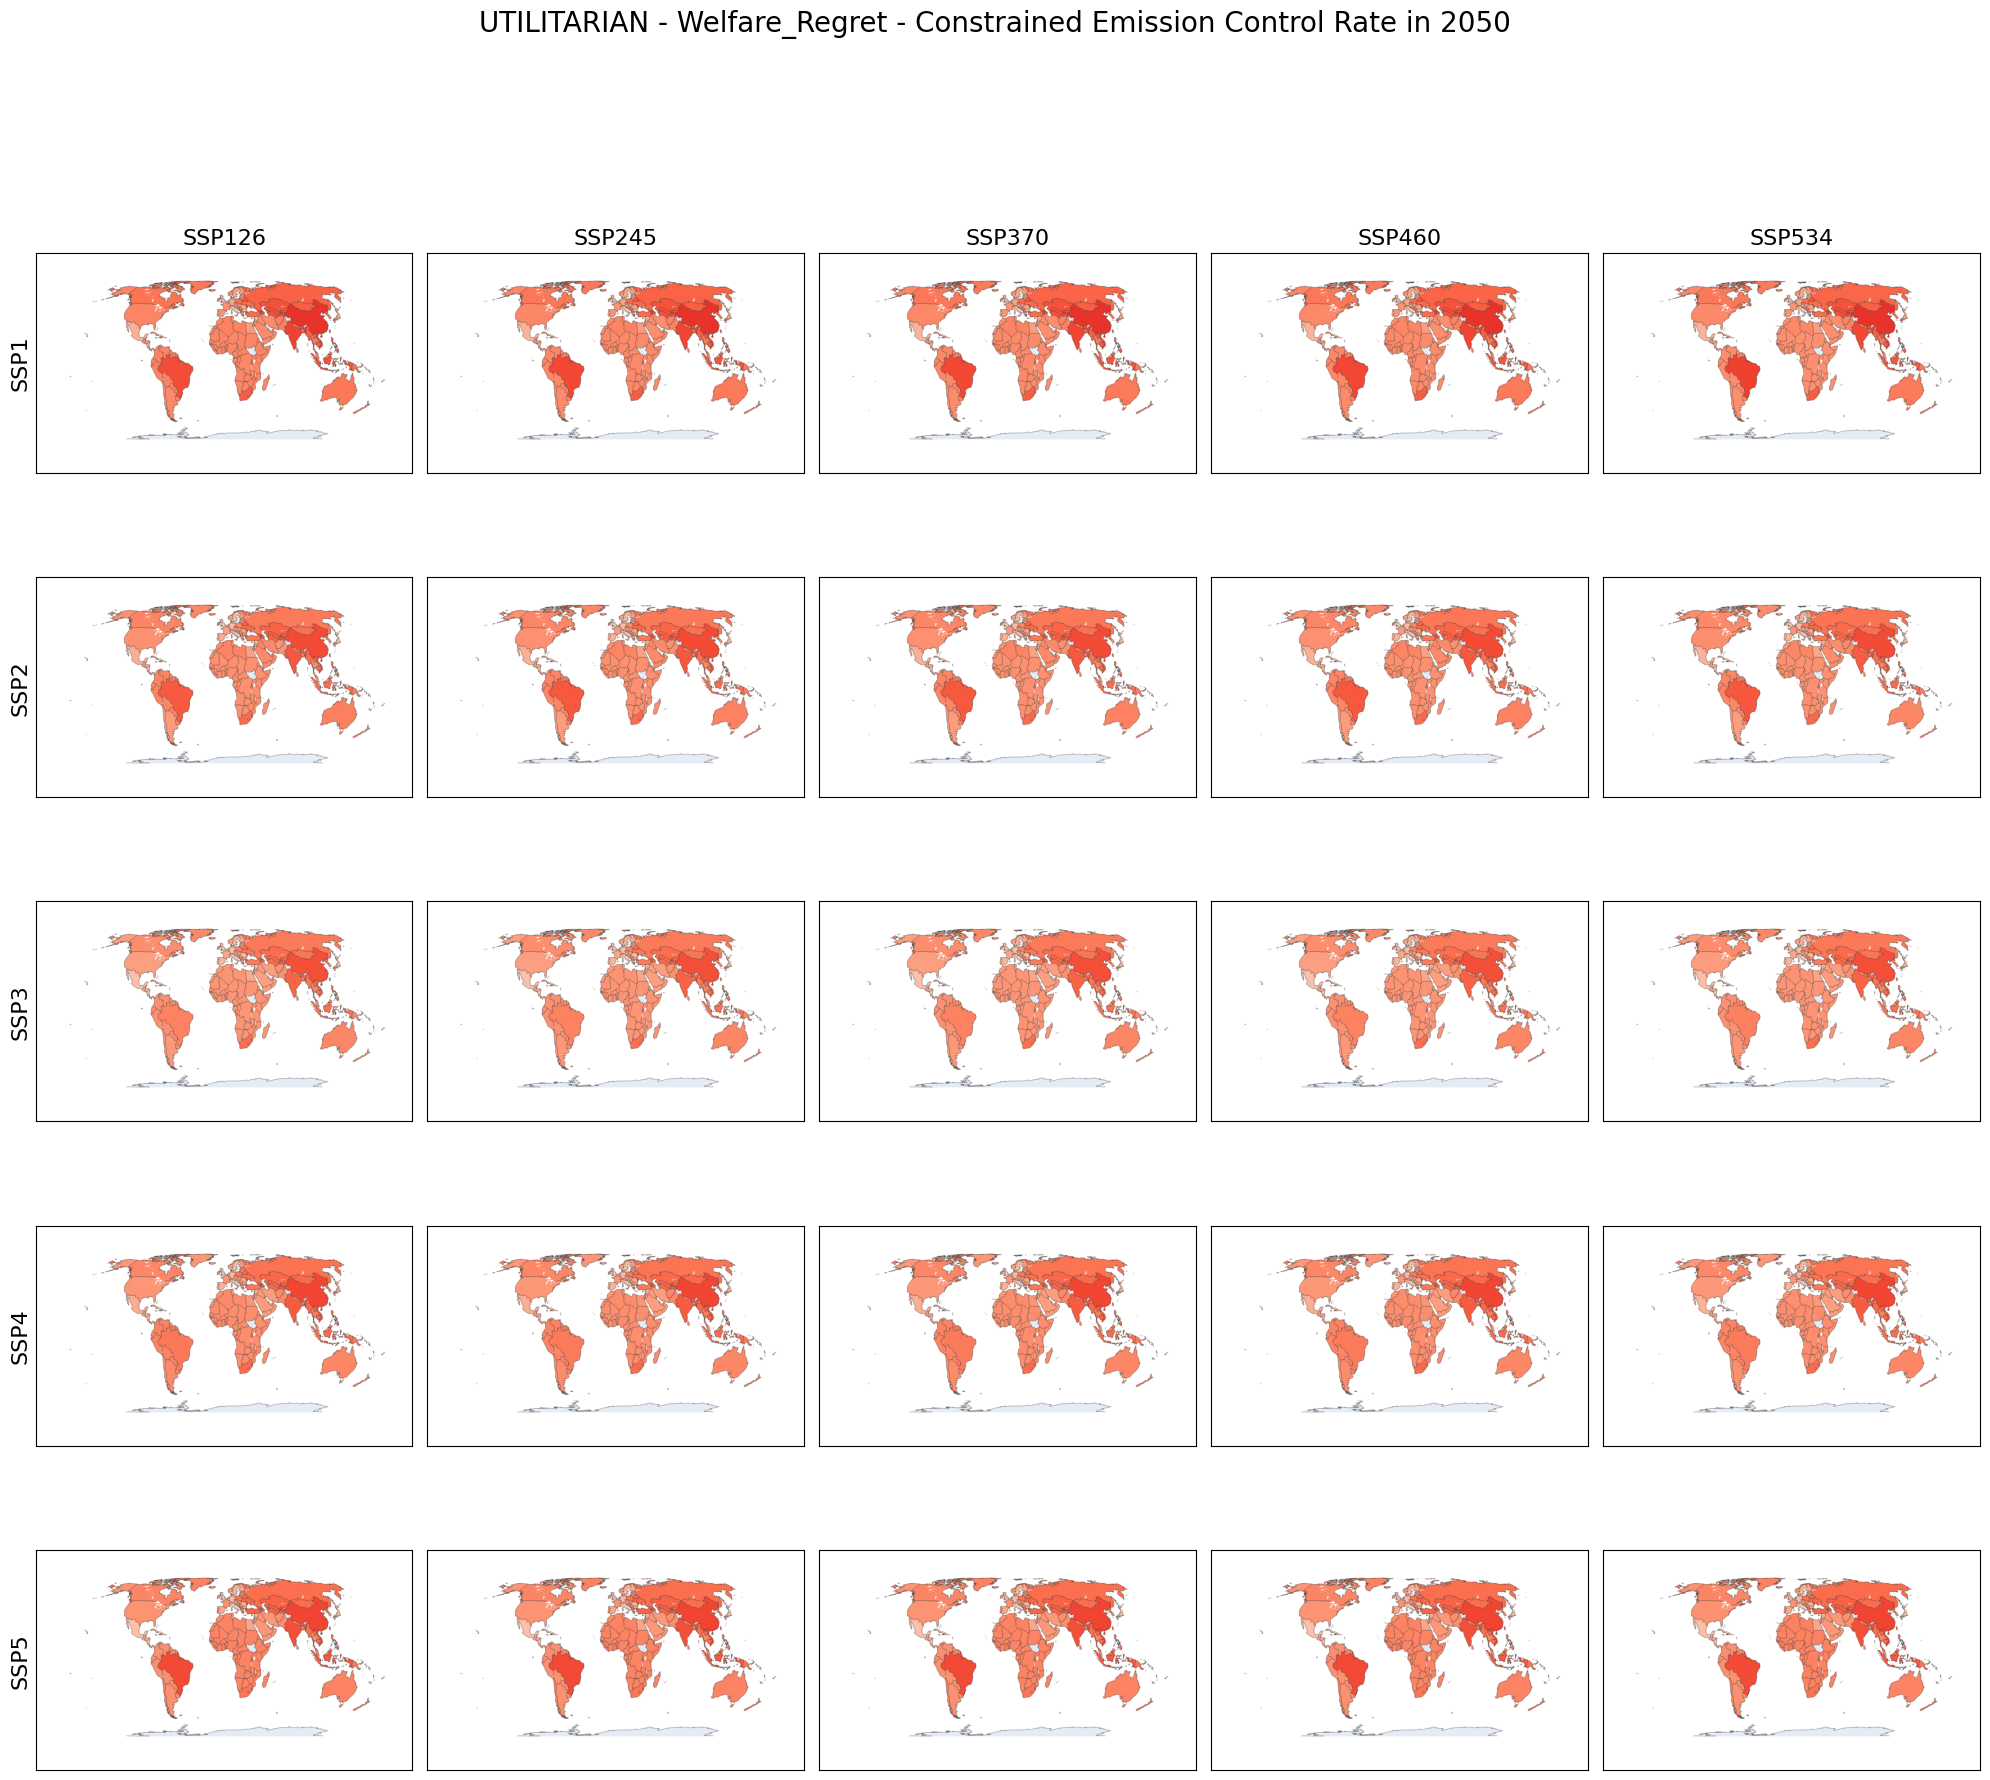

In [ ]:
# This code generates a 5x5 grid of choropleth plots.
# Rows correspond to reference_scenarios and columns to ssps.
# We add rotated row labels on the left and keep column labels on top.

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import json

regret_type = "Welfare_Regret"  # or "Welfare_Regret" "Temperature_Regret"
ethical_framing = "UTILITARIAN"  # or "UTILITARIAN"

fig, axs = plt.subplots(5, 5, figsize=(20, 20))

# Row labels (left side) correspond to reference scenarios
reference_scenarios = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
# Column headers (top) correspond to SSPs
ssps = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

base_path = "data/temporary/NU_DATA/mmBorg/plots/"

# Read the json file with min regret policy indices
with open("data/temporary/NU_DATA/mmBorg/min_regret_policy_indices.json", "r") as f:
    loaded_min_regret_policy_indices = json.load(f)

# Fill the grid with the plots
for i, scenario in enumerate(reference_scenarios):
    for j, ssp in enumerate(ssps):
        policy_index = loaded_min_regret_policy_indices[scenario][ethical_framing][regret_type]
        # Example file name: PRIORITARIAN_ref_SSP1_Welfare_Regret_idx0_SSP534_rate2050.png
        file_name = f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{ssp}_rate2050.png"
        img_path = os.path.join(base_path, file_name)

        try:
            img = mpimg.imread(img_path)
        except FileNotFoundError:
            print(f"Warning: missing {img_path}")
            continue

        ax = axs[i, j]
        ax.imshow(img)

        # Do not turn the axis completely off; hide only the ticks for a clean look
        ax.set_xticks([])
        ax.set_yticks([])

        # Column headers (SSP names) on the top row
        if i == 0:
            ax.set_title(ssp, fontsize=16)

        # Row labels on the left (will be set below)

# Row labels on the left (rotated 90 degrees by default)
for i, scenario in enumerate(reference_scenarios):
    axs[i, 0].set_ylabel(scenario, fontsize=16)

# Improve layout and give space for left labels
plt.subplots_adjust(left=0.28, right=0.98, top=0.95, bottom=0.08)

# Optional: only show outer labels (keeps the left column labels visible)
for ax in axs.flat:
    ax.label_outer()

plt.suptitle(f"{ethical_framing} - {regret_type} - Constrained Emission Control Rate in 2050", fontsize=20)

# Use tight_layout with a rect to avoid overlapping the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and display
output_pdf = os.path.join(base_path, f"{ethical_framing}_{regret_type}_constrained_emission_control_rate_2050_matrix.pdf")
plt.savefig(output_pdf)
plt.show()

# Feature Importance Analysis

In [ ]:
from justice.util.feature_importance import build_long_dataframe, run_all_ml_importance

years = (2030, 2040, 2050, 2060, 2070,  2080, 2090, 2100) #(2030, 2050, 2070, 2100),
long_df = build_long_dataframe(
    base_path="data/temporary/NU_DATA/mmBorg/",
    region_mapping_path="data/input/12_regions.json",
    rice_region_dict_path="data/input/rice50_regions_dict.json",
    years_of_interest=years,
)

print("Long DF shape:", long_df.shape)



results = run_all_ml_importance(
    long_df=long_df,
    years=years,
    target_stats=("raw",),
    output_dir="ml_importance_plots",
    cv_folds=5,
    random_state=42,
    model_params=dict(
        depth=6,
        learning_rate=0.05,
        n_estimators=800,
        l2_leaf_reg=3.0,
        loss_function="RMSE",
        random_seed=42,
        od_type="Iter",
        od_wait=50,
        use_best_model=True,
        verbose=False,
        allow_writing_files=False,
    ),
    normalized_plots=True,
    model_type="final",
    scope="global", 
)




Long DF shape: (10410400, 9)
Saving plots to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2030_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2040_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2050_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2060_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2070_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/ml_importance_plots/global/raw/global_2080_shap_full.csv
Saving 

## Stacked Bar Plots of Feature Importance

In [ ]:
from justice.util.visualizer import render_all_grouped_stacked_charts

# Regional
# render_all_grouped_stacked_charts(
#     base_dir="ml_importance_plots",
#     scope="regional",
#     stat="raw",
#     model_type="final",
#     years=(2030, 2050, 2070, 2100),#(2030, 2040, 2050, 2060, 2070,  2080, 2090, 2100), #(2030, 2050, 2070, 2100),
#     group_map={"Deep Uncertainty": ["Scenario"], "Normative Uncertainty": ["Optimization", "Welfare", "Regret"], "Stochastic Uncertainty": ["Sample"]},
#     output_dir="figs",
# )

# Global
# Splitting Normative Uncertainty 
render_all_grouped_stacked_charts(
    base_dir="ml_importance_plots",
    scope="global",
    stat="raw",
    model_type="final",
    years=(2030, 2040, 2050, 2060, 2070,  2080, 2090, 2100), #(2030, 2050, 2070, 2100),
    # None for split version and the commented one for combined version
    group_map={"Deep Uncertainty": ["Scenario"], "Normative Uncertainty": ["Optimization", "Welfare", "Regret"], "Stochastic Uncertainty": ["Sample"]}, #None
    output_dir="figs",
)

[info] Saving figure to figs/global_raw_final_stacked.svg


{'data':    Year  Scenario    Regret   Welfare  Optimization    Sample
 0  2030  0.593274  0.057830  0.100602      0.203194  0.045100
 1  2040  0.472755  0.231374  0.193063      0.064074  0.038735
 2  2050  0.399137  0.219097  0.211700      0.129393  0.040673
 3  2060  0.460422  0.233514  0.193652      0.091670  0.020742
 4  2070  0.471956  0.210437  0.168935      0.127727  0.020945
 5  2080  0.504458  0.175456  0.143217      0.146766  0.030103
 6  2090  0.549459  0.135998  0.118391      0.154815  0.041337
 7  2100  0.592312  0.111174  0.095021      0.159105  0.042388,
 'figure': <Figure size 900x600 with 1 Axes>}

In [ ]:
long_df.head()

,Optimization,Regret,Scenario,Welfare,Region,Year,Sample,AbatedEmission,Scope
0,SSP1,Temperature_Regret,SSP126,UTILITARIAN,Rest of the World,2030,0,0.447325,Regional
1,SSP1,Temperature_Regret,SSP126,UTILITARIAN,Rest of the World,2030,1,0.447762,Regional
2,SSP1,Temperature_Regret,SSP126,UTILITARIAN,Rest of the World,2030,2,0.449517,Regional
3,SSP1,Temperature_Regret,SSP126,UTILITARIAN,Rest of the World,2030,3,0.447558,Regional
4,SSP1,Temperature_Regret,SSP126,UTILITARIAN,Rest of the World,2030,4,0.448138,Regional


# Ternary and Choropleth Maps

In [ ]:
from justice.util.visualizer import generate_uncertainty_visualizations

if __name__ == "__main__":
    base_dir = "ml_importance_plots"
    region_mapping_path = "data/input/12_regions.json"
    fig_map, results = generate_uncertainty_visualizations(
        base_dir=base_dir,
        region_mapping_path=region_mapping_path,
        stat="raw",
        model_type="final",
        years=(2030, 2050, 2070, 2100),
        ternary_scale=8,
        quantize=True,
        annotate_points=True,
        marker_size=40,
        jitter_strength=0.02,
        random_state=0,
        output_dir="figs",
    )
    print("Saved figures:", results)
    fig_map.show()

Saved figures: {2030: {'ternary': PosixPath('figs/ternary_2030.svg'), 'choropleth': PosixPath('figs/choropleth_2030.svg')}, 2050: {'ternary': PosixPath('figs/ternary_2050.svg'), 'choropleth': PosixPath('figs/choropleth_2050.svg')}, 2070: {'ternary': PosixPath('figs/ternary_2070.svg'), 'choropleth': PosixPath('figs/choropleth_2070.svg')}, 2100: {'ternary': PosixPath('figs/ternary_2100.svg'), 'choropleth': PosixPath('figs/choropleth_2100.svg')}}
